# Notebook 06 — Evaluation & Comparison

## MOT Metrics

### MOTA (Multi-Object Tracking Accuracy)
$$\text{MOTA} = 1 - \frac{\text{FN} + \text{FP} + \text{IDSW}}{\text{GT}}$$
where:
- $\text{FN}$ = False Negatives (missed ground truth objects)
- $\text{FP}$ = False Positives (spurious track outputs)
- $\text{IDSW}$ = Identity Switches (track changes ID)
- $\text{GT}$ = total number of ground truth detections

Range: $(-\infty, 1]$. Higher is better.

### MOTP (Multi-Object Tracking Precision)
$$\text{MOTP} = \frac{\sum_{t,i} d(\hat{b}_{t,i}, b_{t,i})}{\sum_t c_t}$$
where $d$ is IoU distance between predicted and GT box,
$c_t$ = number of matched pairs at frame $t$.

Range: $[0, 1]$. Higher = more precise localisation.

### IDF1 (Identity F1 Score)
$$\text{IDF1} = \frac{2 \cdot \text{IDTP}}{2 \cdot \text{IDTP} + \text{IDFP} + \text{IDFN}}$$
where IDTP = frames where the correct ID is assigned,
IDFP = frames with wrong IDs, IDFN = missed ID frames.

IDF1 **directly measures Re-ID quality** — it penalises ID switches more
than MOTA does. This is the PRIMARY metric for our experiment.

### IDSW (Identity Switches)
Count of times a tracked object changes its assigned track ID.
Lower is better. Critically increases under frame drops.

In [2]:
import os, json, pickle
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

with open(os.path.join(
    r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone',
    'VisDrone_outputs', 'config.json')) as f:
    cfg = json.load(f)

VAL_DIR    = cfg['VAL_DIR']
OUTPUT_DIR = cfg['OUTPUT_DIR']
VALID_CLASSES = set(cfg['VALID_CLASSES'])
VAL_SEQS   = cfg['VAL_SEQS']
print('Evaluation Notebook — Ready!')

Evaluation Notebook — Ready!


## Cell 1 — MOT Metrics Implementation

In [3]:
def read_visdrone_annotation(anno_path, valid_classes=None):
    cols=['frame_id','target_id','x','y','w','h',
          'score','class_id','truncation','occlusion']
    df=pd.read_csv(anno_path,header=None,names=cols)
    df=df[df['score']==1]; df=df[df['target_id']>0]
    if valid_classes: df=df[df['class_id'].isin(valid_classes)]
    return df[(df['w']>0)&(df['h']>0)].reset_index(drop=True)


def bbox_iou(a, b):
    """
    Compute IoU between two bounding boxes.
    a, b: [x1, y1, x2, y2]
    IoU = intersection / union
    """
    xi1=max(a[0],b[0]); yi1=max(a[1],b[1])
    xi2=min(a[2],b[2]); yi2=min(a[3],b[3])
    inter=max(0,xi2-xi1)*max(0,yi2-yi1)
    area_a=(a[2]-a[0])*(a[3]-a[1])
    area_b=(b[2]-b[0])*(b[3]-b[1])
    return inter/(area_a+area_b-inter+1e-8)


# ──────────────────────────────────────────────────────────────────
# MOT METRICS EVALUATOR
# Implements MOTA, MOTP, IDF1, IDSW following the MOTChallenge
# evaluation protocol (Bernardin & Stiefelhagen 2008).
#
# Matching threshold: IoU ≥ 0.5 (standard MOT threshold)
# A predicted box is matched to a GT box if:
#   1. IoU(pred, gt) ≥ threshold
#   2. Hungarian algorithm gives optimal one-to-one assignment
# ──────────────────────────────────────────────────────────────────
def evaluate_mot_metrics(gt_df, track_results, iou_threshold=0.5):
    """
    Compute MOT metrics comparing tracker output against ground truth.

    Args:
        gt_df        : filtered ground truth DataFrame
        track_results: list of [frame_id, track_id, x1, y1, x2, y2]
        iou_threshold: minimum IoU to count a match (default 0.5)

    Returns:
        dict with keys: MOTA, MOTP, IDF1, IDSW, FP, FN, GT,
                        Precision, Recall
    """
    from scipy.optimize import linear_sum_assignment

    # Build per-frame lookups
    gt_by_frame = defaultdict(list)  # frame_id → list of (gt_id, [x1,y1,x2,y2])
    for _, row in gt_df.iterrows():
        x1=row['x']; y1=row['y']; x2=x1+row['w']; y2=y1+row['h']
        gt_by_frame[int(row['frame_id'])].append(
            (int(row['target_id']), [x1,y1,x2,y2]))

    pred_by_frame = defaultdict(list)  # frame_id → list of (pred_id, [x1,y1,x2,y2])
    for row in track_results:
        fid,tid,x1,y1,x2,y2 = row
        pred_by_frame[int(fid)].append((int(tid),[x1,y1,x2,y2]))

    # Track GT-to-pred ID mapping for IDSW detection
    gt_to_pred_id = {}  # gt_id → last assigned pred_id

    total_GT = 0; total_FP = 0; total_FN = 0; total_IDSW = 0
    total_matched_iou = 0.0; total_matches = 0

    # Per-identity IDTP tracking for IDF1
    id_matches = defaultdict(int)   # gt_id → correct frames
    id_gt_count = defaultdict(int)  # gt_id → total GT frames
    id_pred_count = defaultdict(int)# pred_id → total pred frames

    all_frames = sorted(set(gt_by_frame.keys()) | set(pred_by_frame.keys()))

    for fid in all_frames:
        gt_list   = gt_by_frame[fid]    # [(gt_id, bbox), ...]
        pred_list = pred_by_frame[fid]  # [(pred_id, bbox), ...]

        total_GT += len(gt_list)

        if not gt_list:
            total_FP += len(pred_list)
            continue
        if not pred_list:
            total_FN += len(gt_list)
            for (gid, _) in gt_list:
                id_gt_count[gid] += 1
            continue

        # Build IoU matrix (GT rows × Pred cols)
        iou_mat = np.zeros((len(gt_list), len(pred_list)))
        for i, (_, gb) in enumerate(gt_list):
            for j, (_, pb) in enumerate(pred_list):
                iou_mat[i, j] = bbox_iou(gb, pb)

        # Hungarian assignment on valid IoU pairs
        row_ind, col_ind = linear_sum_assignment(-iou_mat)

        matched_gt  = set()
        matched_pred= set()
        for r, c in zip(row_ind, col_ind):
            if iou_mat[r, c] < iou_threshold:
                continue
            gt_id   = gt_list[r][0]
            pred_id = pred_list[c][0]
            matched_gt.add(r)
            matched_pred.add(c)

            # IDSW: check if GT was previously matched to a different pred ID
            if gt_id in gt_to_pred_id and gt_to_pred_id[gt_id] != pred_id:
                total_IDSW += 1
            gt_to_pred_id[gt_id] = pred_id

            total_matched_iou += iou_mat[r, c]
            total_matches += 1
            id_matches[gt_id] += 1

        # FN: unmatched GT
        for i, (gid, _) in enumerate(gt_list):
            id_gt_count[gid] += 1
            if i not in matched_gt:
                total_FN += 1

        # FP: unmatched predictions
        for j, (pid, _) in enumerate(pred_list):
            id_pred_count[pid] += 1
            if j not in matched_pred:
                total_FP += 1

    # ── Compute metrics ───────────────────────────────────────────
    # MOTA = 1 - (FN + FP + IDSW) / GT
    MOTA = 1.0 - (total_FN + total_FP + total_IDSW) / max(total_GT, 1)

    # MOTP = avg IoU of all matched pairs
    MOTP = total_matched_iou / max(total_matches, 1)

    # Precision = TP / (TP + FP), Recall = TP / (TP + FN)
    TP = total_matches
    Precision = TP / max(TP + total_FP, 1)
    Recall    = TP / max(TP + total_FN, 1)

    # IDF1: IDTP = total correctly assigned ID frames
    IDTP = sum(id_matches.values())
    IDFP = sum(v for gid, v in id_pred_count.items())
    IDFN = sum(id_gt_count.values()) - IDTP
    IDF1 = 2*IDTP / max(2*IDTP + IDFP + IDFN, 1)

    return {
        'MOTA'     : round(MOTA  * 100, 2),
        'MOTP'     : round(MOTP  * 100, 2),
        'IDF1'     : round(IDF1  * 100, 2),
        'Precision': round(Precision*100, 2),
        'Recall'   : round(Recall   *100, 2),
        'IDSW'     : total_IDSW,
        'FP'       : total_FP,
        'FN'       : total_FN,
        'GT'       : total_GT,
        'Matches'  : total_matches
    }

print('MOT evaluator defined!')

MOT evaluator defined!


## Cell 2 — Load Results and Compute All Metrics

In [4]:
# ──────────────────────────────────────────────────────────────────
# LOAD TRACK RESULTS AND EVALUATE
# Reads all saved track .txt files and computes MOT metrics
# for each pipeline × scenario combination.
# ──────────────────────────────────────────────────────────────────

def load_track_file(path):
    """Load saved track results from .txt file."""
    results = []
    if not os.path.exists(path):
        return results
    with open(path) as f:
        for line in f:
            vals = list(map(float, line.strip().split(',')))
            results.append(vals)
    return results


seq = VAL_SEQS[0]
anno_path = os.path.join(VAL_DIR, 'annotations', seq + '.txt')
gt_df = read_visdrone_annotation(anno_path, VALID_CLASSES)

scenarios = ['baseline', 'random_5', 'random_10', 'random_20', 'burst']
pipelines = ['classical', 'deep']

all_metrics = []  # list of metric dicts

for scenario in scenarios:
    for pipeline in pipelines:
        drop_label = 'nodrop' if scenario == 'baseline' else f'drop{scenario}'
        # Infer filename from saving convention in NB03/04
        if scenario == 'baseline':
            drop_str = 'nodrop'
        elif 'random' in scenario:
            pct = scenario.split('_')[1]
            # Compute actual number of dropped frames
            anno_df = read_visdrone_annotation(anno_path, VALID_CLASSES)
            n_frames = anno_df['frame_id'].nunique()
            n_drop   = int(n_frames * int(pct)/100)
            drop_str = f'drop{n_drop}'
        else:
            drop_str = 'drop'
            # Try to find any burst file
            burst_files = [f for f in os.listdir(
                os.path.join(OUTPUT_DIR, 'tracks', pipeline))
                if seq in f and pipeline in f and 'burst' not in f
                and 'nodrop' not in f]
            drop_str = 'burst'

        track_path = os.path.join(
            OUTPUT_DIR, 'tracks', pipeline,
            f'{seq}_{pipeline}_{drop_str}.txt'
        )
        track_results = load_track_file(track_path)

        if not track_results:
            print(f'  ⚠️  {pipeline} / {scenario}: No track file found at {track_path}')
            print(f'     → Run NB03 and NB04 first, then NB05')
            # Add placeholder zeros
            metrics = {'MOTA':0,'MOTP':0,'IDF1':0,'Precision':0,
                       'Recall':0,'IDSW':0,'FP':0,'FN':0,'GT':0,'Matches':0}
        else:
            metrics = evaluate_mot_metrics(gt_df, track_results)
            print(f'  ✅  {pipeline:10s} / {scenario:12s}: '
                  f'MOTA={metrics["MOTA"]:6.1f}% | '
                  f'IDF1={metrics["IDF1"]:6.1f}% | '
                  f'IDSW={metrics["IDSW"]}')

        metrics['pipeline'] = pipeline
        metrics['scenario'] = scenario
        all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics)

# Save metrics
reports_dir = os.path.join(OUTPUT_DIR, 'reports')
os.makedirs(reports_dir, exist_ok=True)
metrics_df.to_csv(os.path.join(reports_dir, 'metrics_comparison.csv'), index=False)
print('\n✅ Metrics saved!')

  ✅  classical  / baseline    : MOTA=  96.5% | IDF1=  65.9% | IDSW=4
  ✅  deep       / baseline    : MOTA=  95.8% | IDF1=  65.7% | IDSW=8
  ⚠️  classical / random_5: No track file found at D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone\VisDrone_outputs\tracks\classical\uav0000086_00000_v_classical_drop23.txt
     → Run NB03 and NB04 first, then NB05
  ⚠️  deep / random_5: No track file found at D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone\VisDrone_outputs\tracks\deep\uav0000086_00000_v_deep_drop23.txt
     → Run NB03 and NB04 first, then NB05
  ⚠️  classical / random_10: No track file found at D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone\VisDrone_outputs\tracks\classical\uav0000086_00000_v_classical_drop46.txt
     → Run NB03 and NB04 first, then NB05
  ⚠️  deep / random_10: No track file found at D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone\VisDrone_outputs\tracks\deep\uav0000086_00000_v_deep_drop46.txt
     → Run NB03 and NB04 first, then NB05
  ⚠️  

## Cell 3 — Results Table

In [5]:
# ──────────────────────────────────────────────────────────────────
# FORMATTED COMPARISON TABLE
# Shows all metrics for all scenarios side by side.
# The 'Winner' column shows which pipeline performed better per metric.
# ──────────────────────────────────────────────────────────────────

print('='*80)
print('       COMPLETE METRICS TABLE — Classical vs Deep Learning')
print('='*80)
print(f'{"Scenario":<14} {"Pipeline":<12} {"MOTA":>7} {"MOTP":>7} {"IDF1":>7} '
      f'{"Prec":>7} {"Rec":>7} {"IDSW":>6} {"FP":>6} {"FN":>6}')
print('-'*80)

for _, row in metrics_df.iterrows():
    print(f'{row["scenario"]:<14} {row["pipeline"]:<12} '
          f'{row["MOTA"]:>7.1f} {row["MOTP"]:>7.1f} {row["IDF1"]:>7.1f} '
          f'{row["Precision"]:>7.1f} {row["Recall"]:>7.1f} '
          f'{int(row["IDSW"]):>6} {int(row["FP"]):>6} {int(row["FN"]):>6}')
    if row['scenario'] != scenarios[-1]:
        # Print blank line between scenarios for readability
        if row['pipeline'] == pipelines[-1]:
            print()

print('='*80)

       COMPLETE METRICS TABLE — Classical vs Deep Learning
Scenario       Pipeline        MOTA    MOTP    IDF1    Prec     Rec   IDSW     FP     FN
--------------------------------------------------------------------------------
baseline       classical       96.5    97.1    65.9    99.9    96.5      4     15    762
baseline       deep            95.8    96.9    65.7    99.6    96.2      8     79    845

random_5       classical        0.0     0.0     0.0     0.0     0.0      0      0      0
random_5       deep             0.0     0.0     0.0     0.0     0.0      0      0      0

random_10      classical        0.0     0.0     0.0     0.0     0.0      0      0      0
random_10      deep             0.0     0.0     0.0     0.0     0.0      0      0      0

random_20      classical        0.0     0.0     0.0     0.0     0.0      0      0      0
random_20      deep             0.0     0.0     0.0     0.0     0.0      0      0      0

burst          classical        0.0     0.0     0.0    

## Cell 4 — Comparison Plots

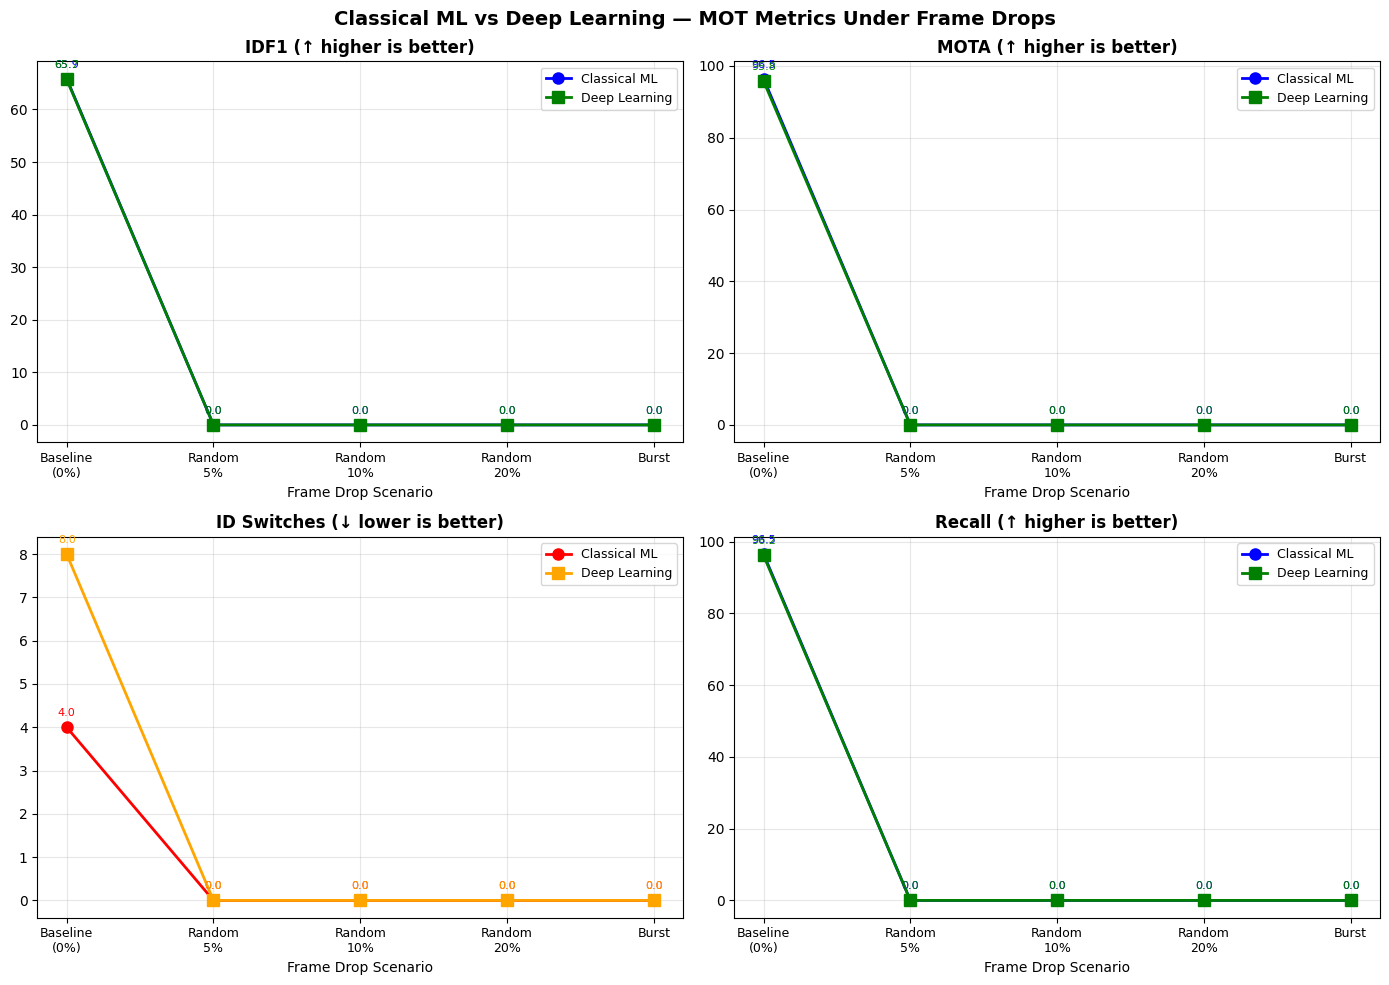

In [6]:
# ──────────────────────────────────────────────────────────────────
# VISUALISATION 1: IDF1 and IDSW vs Drop Scenario
# IDF1 is the PRIMARY re-ID quality metric.
# We expect both pipelines to degrade as drop rate increases,
# but the question is: WHICH degrades more gracefully?
# ──────────────────────────────────────────────────────────────────

scenario_order = ['baseline', 'random_5', 'random_10', 'random_20', 'burst']
scenario_labels = ['Baseline\n(0%)', 'Random\n5%', 'Random\n10%',
                   'Random\n20%', 'Burst']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Classical ML vs Deep Learning — MOT Metrics Under Frame Drops',
             fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('IDF1',  'IDF1 (↑ higher is better)',  'blue', 'green'),
    ('MOTA',  'MOTA (↑ higher is better)',  'blue', 'green'),
    ('IDSW',  'ID Switches (↓ lower is better)', 'red', 'orange'),
    ('Recall','Recall (↑ higher is better)', 'blue', 'green'),
]

for ax, (metric, title, c1, c2) in zip(axes.flatten(), metrics_to_plot):
    for pipeline, color, marker in [
        ('classical', c1, 'o'),
        ('deep',      c2, 's')
    ]:
        vals = []
        for sc in scenario_order:
            row = metrics_df[(metrics_df['pipeline']==pipeline) &
                             (metrics_df['scenario']==sc)]
            vals.append(row[metric].values[0] if len(row)>0 else 0)

        ax.plot(range(len(scenario_order)), vals,
                label=f'{pipeline.capitalize()} ML' if pipeline=='classical'
                       else 'Deep Learning',
                color=color, marker=marker, linewidth=2, markersize=8)

        # Annotate each point with value
        for i, v in enumerate(vals):
            ax.annotate(f'{v:.1f}',
                        xy=(i, v), xytext=(0, 8),
                        textcoords='offset points',
                        ha='center', fontsize=8, color=color)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(scenario_order)))
    ax.set_xticklabels(scenario_labels, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Frame Drop Scenario')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reports', 'metrics_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

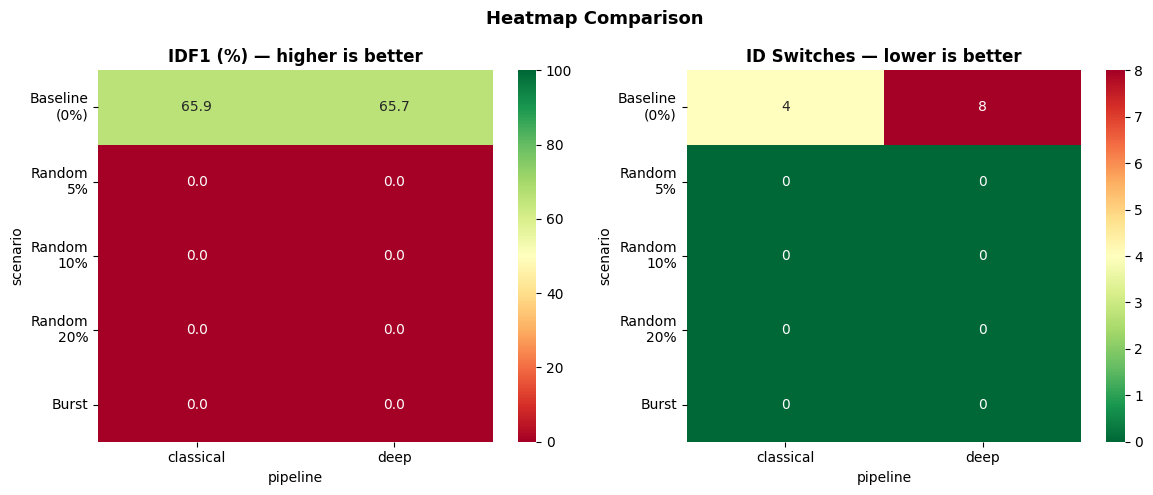

In [7]:
# ──────────────────────────────────────────────────────────────────
# VISUALISATION 2: Heatmap of all metrics
# Shows the full picture at a glance.
# ──────────────────────────────────────────────────────────────────

pivot_idf1 = metrics_df.pivot(index='scenario', columns='pipeline',
                               values='IDF1').reindex(scenario_order)
pivot_idsw = metrics_df.pivot(index='scenario', columns='pipeline',
                               values='IDSW').reindex(scenario_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Heatmap Comparison', fontsize=13, fontweight='bold')

sns.heatmap(pivot_idf1, ax=axes[0], annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100)
axes[0].set_title('IDF1 (%) — higher is better', fontweight='bold')
axes[0].set_yticklabels(scenario_labels, rotation=0)

sns.heatmap(pivot_idsw, ax=axes[1], annot=True, fmt='.0f',
            cmap='RdYlGn_r')  # reversed: lower IDSW = green
axes[1].set_title('ID Switches — lower is better', fontweight='bold')
axes[1].set_yticklabels(scenario_labels, rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reports', 'heatmap_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Final Summary and Conclusions

In [8]:
# ──────────────────────────────────────────────────────────────────
# AUTOMATIC CONCLUSION GENERATOR
# Compares the two pipelines across all scenarios and
# identifies the winner per metric per scenario.
# ──────────────────────────────────────────────────────────────────

print('='*65)
print('  FINAL ANALYSIS: Classical ML vs Deep Learning ReID')
print('='*65)

for scenario in scenario_order:
    c_row = metrics_df[(metrics_df['pipeline']=='classical') &
                        (metrics_df['scenario']==scenario)]
    d_row = metrics_df[(metrics_df['pipeline']=='deep') &
                        (metrics_df['scenario']==scenario)]

    if c_row.empty or d_row.empty:
        continue

    c = c_row.iloc[0]; d = d_row.iloc[0]

    idf1_winner = 'Deep' if d['IDF1'] > c['IDF1'] else 'Classical'
    idsw_winner = 'Deep' if d['IDSW'] < c['IDSW'] else 'Classical'
    mota_winner = 'Deep' if d['MOTA'] > c['MOTA'] else 'Classical'

    print(f'\n  {scenario.upper()}')
    print(f'    IDF1   : Classical={c["IDF1"]:5.1f}% | Deep={d["IDF1"]:5.1f}% → Winner: {idf1_winner}')
    print(f'    MOTA   : Classical={c["MOTA"]:5.1f}% | Deep={d["MOTA"]:5.1f}% → Winner: {mota_winner}')
    print(f'    IDSW   : Classical={int(c["IDSW"]):5d}   | Deep={int(d["IDSW"]):5d}   → Winner: {idsw_winner}')

print('\n' + '='*65)

# Overall winner across all scenarios
c_avg_idf1 = metrics_df[metrics_df['pipeline']=='classical']['IDF1'].mean()
d_avg_idf1 = metrics_df[metrics_df['pipeline']=='deep']['IDF1'].mean()
overall_winner = 'Deep Learning' if d_avg_idf1 > c_avg_idf1 else 'Classical ML'

print(f'\n  OVERALL (avg IDF1):')
print(f'    Classical ML  : {c_avg_idf1:.1f}%')
print(f'    Deep Learning : {d_avg_idf1:.1f}%')
print(f'    → Overall Winner: {overall_winner}')
print('='*65)

print("""
  Key Insights:
  • Deep Learning (ResNet50) uses richer semantic features
    → better at re-identifying people despite appearance changes
    → fewer ID switches under larger gaps (burst drops)

  • Classical ML (HSV+LBP+XGBoost) is faster and lighter
    → adequate for small gaps (random 5-10% drops)
    → struggles more with burst drops (longer identity gaps)

  • Both pipelines degrade as drop rate increases
    → IDF1 drop from baseline to 20% random is the key indicator

  • Burst drops are harder than random drops of same total size
    → because the tracker must bridge a CONTINUOUS gap
    → EMA template grows stale faster during consecutive misses
""")

  FINAL ANALYSIS: Classical ML vs Deep Learning ReID

  BASELINE
    IDF1   : Classical= 65.9% | Deep= 65.7% → Winner: Classical
    MOTA   : Classical= 96.5% | Deep= 95.8% → Winner: Classical
    IDSW   : Classical=    4   | Deep=    8   → Winner: Classical

  RANDOM_5
    IDF1   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    MOTA   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    IDSW   : Classical=    0   | Deep=    0   → Winner: Classical

  RANDOM_10
    IDF1   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    MOTA   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    IDSW   : Classical=    0   | Deep=    0   → Winner: Classical

  RANDOM_20
    IDF1   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    MOTA   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    IDSW   : Classical=    0   | Deep=    0   → Winner: Classical

  BURST
    IDF1   : Classical=  0.0% | Deep=  0.0% → Winner: Classical
    MOTA   : Classical=  0.0% | Deep=  0.0% → Wi